### Connexion à la DB DuckDB

In [1]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


### Connexion à la DB / Import des Data


In [2]:
# Store database at project root
DB_NAME = Path("../amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [3]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 10 tables in the database:

1. all_events
2. historical_events
3. item_item_sim
4. loaded_files
5. new_events
6. product_popularity
7. segment_popularity
8. user_events
9. user_item_interactions
10. user_segments_kmeans


In [79]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌────────────────────────┐
│          name          │
│        varchar         │
├────────────────────────┤
│ all_events             │
│ historical_events      │
│ item_item_sim          │
│ loaded_files           │
│ new_events             │
│ product_popularity     │
│ segment_popularity     │
│ user_events            │
│ user_item_interactions │
│ user_segments_kmeans   │
├────────────────────────┤
│        10 rows         │
└────────────────────────┘



In [80]:
# Examine the all_events table
print("First 10 rows of all_events table:")
all_events_data = con.sql("""
    SELECT * FROM all_events LIMIT 10
""")
all_events_data.show()


# Examine the loaded_files table
print("\nContents of loaded_files table:")
loaded_files_data = con.sql("""
    SELECT * FROM loaded_files
""")
loaded_files_data.show()


First 10 rows of all_events table:
┌─────────────────────┬────────────┬────────────┬─────────────────────┬────────────────────────────────┬─────────┬─────────┬───────────┬──────────────────────────────────────┐
│     event_time      │ event_type │ product_id │     category_id     │         category_code          │  brand  │  price  │  user_id  │             user_session             │
│      timestamp      │  varchar   │  varchar   │       varchar       │            varchar             │ varchar │ double  │  varchar  │               varchar                │
├─────────────────────┼────────────┼────────────┼─────────────────────┼────────────────────────────────┼─────────┼─────────┼───────────┼──────────────────────────────────────┤
│ 2019-12-01 00:00:00 │ view       │ 1005105    │ 2232732093077520756 │ construction.tools.light       │ apple   │ 1302.48 │ 556695836 │ ca5eefc5-11f9-450c-91ed-380285a0bc80 │
│ 2019-12-01 00:00:00 │ view       │ 22700068   │ 2232732091643068746 │ NULL         

In [81]:
# Examine the all_events table
print("First 10 rows of all_events table:")
all_events_data = con.sql("""
    SELECT * FROM all_events LIMIT 10
""")
all_events_data.show()

# Show count of records in all_events
record_count = con.sql("""
    SELECT COUNT(*) as total_events FROM all_events
""")
record_count.show()

# Examine the loaded_files table
print("\nContents of loaded_files table:")
loaded_files_data = con.sql("""
    SELECT * FROM loaded_files
""")
loaded_files_data.show()


First 10 rows of all_events table:
┌─────────────────────┬────────────┬────────────┬─────────────────────┬────────────────────────────────┬─────────┬─────────┬───────────┬──────────────────────────────────────┐
│     event_time      │ event_type │ product_id │     category_id     │         category_code          │  brand  │  price  │  user_id  │             user_session             │
│      timestamp      │  varchar   │  varchar   │       varchar       │            varchar             │ varchar │ double  │  varchar  │               varchar                │
├─────────────────────┼────────────┼────────────┼─────────────────────┼────────────────────────────────┼─────────┼─────────┼───────────┼──────────────────────────────────────┤
│ 2019-12-01 00:00:00 │ view       │ 1005105    │ 2232732093077520756 │ construction.tools.light       │ apple   │ 1302.48 │ 556695836 │ ca5eefc5-11f9-450c-91ed-380285a0bc80 │
│ 2019-12-01 00:00:00 │ view       │ 22700068   │ 2232732091643068746 │ NULL         

In [4]:
DB_NAME = "amazing.duckdb"
TABLE_EVENTS = "all_events"
TABLE_USER_EVENTS = "user_events"
SAMPLE_USER_PERCENT = 0.01
BATCH_SIZE = 1000 

### Import de la table DuckDB

In [4]:
# Chargement de users avec au moins 10 événements 
print("Chargement d'un échantillon d'utilisateurs actifs...")

# Afficher les tables disponibles dans la base de données
tables_df = con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema = 'main'").fetch_df()
print("Tables disponibles dans la base de données :")
print(tables_df)

user_ids_df = con.execute(f"""
    SELECT user_id
    FROM all_events
    WHERE user_id IS NOT NULL
    GROUP BY user_id
""").fetch_df()

Chargement d'un échantillon d'utilisateurs actifs...
Tables disponibles dans la base de données :
               table_name
0              all_events
1       historical_events
2           item_item_sim
3            loaded_files
4              new_events
5      product_popularity
6      segment_popularity
7             user_events
8  user_item_interactions
9    user_segments_kmeans


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Normalisation et Standardisation des données

In [64]:
user_df = con.execute("""
    SELECT 
        user_id,
        COUNT(*) AS nb_events 
    FROM all_events 
    WHERE user_id IS NOT NULL
    GROUP BY user_id ORDER BY RANDOM()
""").fetch_df()

user_counts = user_df["nb_events"]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [81]:
user_stats_df = con.execute("""
WITH user_agg AS (
    SELECT
        user_id,
        COUNT(*) AS nb_events,
        SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS total_views,
        SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS total_purchases,
        SUM(CASE WHEN event_type = 'purchase' THEN price ELSE 0 END) AS total_spent,
        COALESCE(AVG(CASE WHEN event_type = 'purchase' THEN price END), 0) AS avg_basket
    FROM all_events
    GROUP BY user_id
)
SELECT *,
    CASE 
        WHEN total_views > 0 THEN total_purchases * 1.0 / total_views
        ELSE 0
    END AS conversion_rate
FROM user_agg
""").fetch_df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
user_counts = user_df["nb_events"].values

In [88]:
import numpy as np

def percentile_thresholds(user_counts, percentiles=[25, 50, 75]):
    results = {}
    for p in percentiles:
        threshold = np.percentile(user_counts, p)
        results[p] = int(round(threshold))
    return results

percentile_results = percentile_thresholds(user_counts)

print("Seuils par percentiles :", percentile_results)


Seuils par percentiles : {25: 2, 50: 5, 75: 18}


In [99]:
def geometric_elbow_threshold_log(user_counts):

    y_raw = np.sort(user_counts)
    y = np.log1p(y_raw)
    x = np.arange(len(y))

    line_start = np.array([x[0], y[0]])
    line_end = np.array([x[-1], y[-1]])

    distances = np.abs(
        np.cross(line_end - line_start,
                 np.vstack((x, y)).T - line_start)
    ) / np.linalg.norm(line_end - line_start)

    elbow_index = np.argmax(distances)
    threshold = y_raw[elbow_index]

    return int(threshold)

geom_threshold = geometric_elbow_threshold_log(user_counts)

print("Seuil point d’inflexion géométrique :", geom_threshold)


Seuil point d’inflexion géométrique : 69


In [100]:
def local_variation_threshold(user_counts):

    y = np.sort(user_counts)

    remaining = []
    total_users = len(y)

    thresholds = np.arange(1, int(np.percentile(y, 90)))

    for t in thresholds:
        remaining.append(np.sum(y >= t) / total_users)

    remaining = np.array(remaining)

    delta = np.abs(np.diff(remaining))

    knee_idx = np.argmax(delta < np.percentile(delta, 30))
    threshold = thresholds[knee_idx]

    return int(threshold)

local_threshold = local_variation_threshold(user_counts)

print("Seuil variation locale :", local_threshold)


Seuil variation locale : 42


In [ ]:
def ratio_stability_threshold(user_df, ratio_col="conversion_rate"):

    thresholds = range(1, 21)
    variances = []

    for t in thresholds:
        subset = user_df[user_df["nb_events"] >= t]
        variances.append(subset[ratio_col].var())

    variances = np.array(variances)

    # On cherche où la variance devient relativement stable
    delta_var = np.abs(np.diff(variances))
    idx = np.argmax(delta_var < np.percentile(delta_var, 25))

    return thresholds[idx]

ratio_threshold = ratio_stability_threshold(user_stats_df)

print("Seuil stabilité ratio :", ratio_threshold)


Seuil stabilité ratio : 15


In [84]:
def statistical_error_threshold(p=0.2, max_error=0.2):

    # p = conversion moyenne estimée
    # max_error = erreur acceptable

    for n in range(1, 50):
        error = np.sqrt(p * (1 - p) / n)
        if error <= max_error:
            return n

    return None

stat_threshold = statistical_error_threshold(p=0.2, max_error=0.2)

print("Seuil basé sur erreur statistique :", stat_threshold)


Seuil basé sur erreur statistique : 4


In [68]:
user_counts = user_df["nb_events"]

stats = user_counts.describe(percentiles=[0.25, 0.5, 0.75]).round(2)
mediane = stats["50%"]
print(stats)


count    15639803.00
mean           26.32
std           111.73
min             1.00
25%             2.00
50%             5.00
75%            18.00
max        199179.00
Name: nb_events, dtype: float64


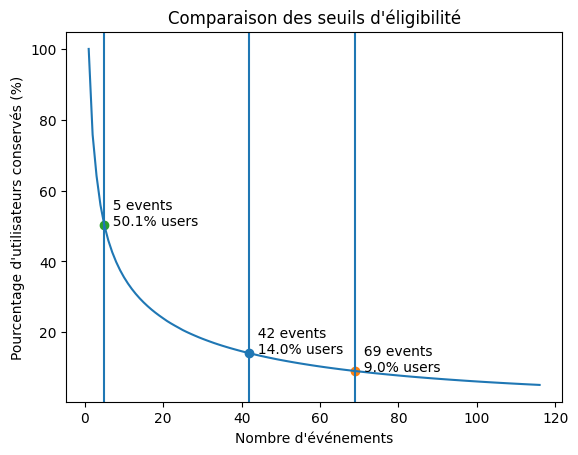

In [101]:
user_counts = user_df["nb_events"].values
total_users = len(user_counts)

max_threshold = int(np.percentile(user_counts, 95))
thresholds = np.arange(1, max_threshold)

remaining_percentages = []

for t in thresholds:
    remaining = np.sum(user_counts >= t)
    remaining_percentages.append((remaining / total_users) * 100)

remaining_percentages = np.array(remaining_percentages)

thresholds_to_show = [local_threshold, geom_threshold, 5]

plt.figure()
plt.plot(thresholds, remaining_percentages)

for t in thresholds_to_show:
    if t < max_threshold:
        pct = (np.sum(user_counts >= t) / total_users) * 100
        plt.axvline(x=t)
        plt.scatter(t, pct)
        plt.text(t, pct, f"  {t} events\n  {pct:.1f}% users")

plt.xlabel("Nombre d'événements")
plt.ylabel("Pourcentage d'utilisateurs conservés (%)")
plt.title("Comparaison des seuils d'éligibilité")
plt.show()


In [5]:
def get_available_months(con: duckdb.DuckDBPyConnection, table_events: str = "all_events") -> List[str]:
    """
    Retourne la liste des mois disponibles dans la table d'événements
    au format YYYY_MM.
    """
    query = f"""
    SELECT DISTINCT STRFTIME(DATE_TRUNC('month', event_time), '%Y_%m') AS event_month
    FROM {table_events}
    WHERE event_time IS NOT NULL
    ORDER BY event_month
    """
    rows = con.execute(query).fetchall()
    return [row[0] for row in rows]


def create_user_events_month_table(
    con: duckdb.DuckDBPyConnection,
    month_str: str,
    table_events: str = "all_events",
    min_events: int = 5
) -> str:
    """
    Crée une table user_events_YYYY_MM pour un mois donné.
    month_str doit être au format 'YYYY_MM'.
    """
    table_name = f"user_events_{month_str}"
    month_filter = month_str.replace("_", "-")

    query = f"""
    CREATE OR REPLACE TABLE {table_name} AS
    WITH base_events AS (
        SELECT
            user_id,
            event_type,
            event_time,
            price,
            LEAD(event_time) OVER (
                PARTITION BY user_id
                ORDER BY event_time
            ) AS next_event_time
        FROM {table_events}
        WHERE user_id IS NOT NULL
          AND STRFTIME(DATE_TRUNC('month', event_time), '%Y-%m') = '{month_filter}'
    ),
    features AS (
        SELECT
            user_id,
            COUNT(*) AS total_events,
            SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS total_views,
            SUM(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS total_carts,
            SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS total_purchases,
            AVG(EXTRACT(EPOCH FROM (next_event_time - event_time))) AS avg_time_between_events,
            SUM(CASE WHEN event_type = 'purchase' THEN price ELSE 0 END) AS total_spent,
            COALESCE(AVG(CASE WHEN event_type = 'purchase' THEN price END), 0) AS avg_basket,
            MAX(event_time) AS last_event_time
        FROM base_events
        GROUP BY user_id
    )
    SELECT
        user_id,
        DATE '{month_filter}-01' AS event_month,
        total_events,
        total_views,
        total_carts,
        total_purchases,
        avg_time_between_events,
        total_spent,
        avg_basket,
        last_event_time,
        CASE
            WHEN (total_views + total_carts) > 0
            THEN total_purchases * 1.0 / (total_views + total_carts)
            ELSE 0
        END AS conversion_rate,
        CASE
            WHEN total_events > 0
            THEN total_purchases * 1.0 / total_events
            ELSE 0
        END AS purchase_ratio,
        DATE_DIFF(
            'day',
            CAST(last_event_time AS DATE),
            LAST_DAY(DATE '{month_filter}-01')
        ) AS days_since_last_event,
        CASE
            WHEN total_events >= {min_events} THEN TRUE
            ELSE FALSE
        END AS is_flagged_user
    FROM features
    """
    con.execute(query)
    return table_name


def create_all_user_events_month_tables(
    con: duckdb.DuckDBPyConnection,
    table_events: str = "all_events",
    min_events: int = 5
) -> List[str]:
    """
    Crée toutes les tables user_events_YYYY_MM à partir des mois présents
    dans all_events.
    """
    months = get_available_months(con, table_events=table_events)
    created_tables = []

    print(f"{len(months)} mois détectés : {months}")

    for month_str in months:
        table_name = create_user_events_month_table(
            con=con,
            month_str=month_str,
            table_events=table_events,
            min_events=min_events
        )
        created_tables.append(table_name)
        print(f"Table créée : {table_name}")

    return created_tables

In [7]:
created_tables = create_all_user_events_month_tables(
    con,
    table_events="all_events",
    min_events=5
)

print("Tables créées :")
for t in created_tables:
    print("-", t)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

7 mois détectés : ['2019_10', '2019_11', '2019_12', '2020_01', '2020_02', '2020_03', '2020_04']


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Table créée : user_events_2019_10


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

Table créée : user_events_2020_02


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Table créée : user_events_2020_03


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Table créée : user_events_2020_04
Tables créées :
- user_events_2019_10
- user_events_2019_11
- user_events_2019_12
- user_events_2020_01
- user_events_2020_02
- user_events_2020_03
- user_events_2020_04


In [8]:
con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
      AND table_name LIKE 'user_events_%'
    ORDER BY table_name
""").fetch_df()

,table_name
0,user_events_2019_10
1,user_events_2019_11
2,user_events_2019_12
3,user_events_2020_01
4,user_events_2020_02
5,user_events_2020_03
6,user_events_2020_04


In [182]:
con.execute("""
    SELECT COUNT(user_id) AS nb_users
    FROM user_events
""").fetch_df()

,nb_users
0,28470


In [187]:
con.execute("""
    SELECT COUNT(*) AS total_rows
    FROM user_events
""").fetch_df()

,total_rows
0,28470


In [174]:
con.execute("""
    SELECT COUNT(*) AS nb_anomalies
    FROM user_events
    WHERE conversion_rate > 1 AND is_flagged_user  = TRUE
""").fetch_df()

,nb_anomalies
0,0


In [173]:
con.execute("""
    SELECT COUNT(*) AS total_rows
    FROM user_events
""").fetch_df()


,total_rows
0,28470


In [186]:
con.execute("""
    SELECT *
    FROM user_events
    WHERE conversion_rate > 0 AND is_flagged_user  = TRUE
""").fetch_df()

,user_id,event_month_date,event_month,month_name,total_events,total_views,total_carts,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event,is_flagged_user
0,559868810,2020-03-01,2020-03,March,107,104.0,2.0,1.0,23108.471698,154.42,154.420000,2020-03-30 12:15:57,0.009434,0.009346,1,True
1,557280430,2019-10-01,2019-10,October,49,45.0,3.0,1.0,27159.916667,321.73,321.730000,2019-10-21 10:08:45,0.020833,0.020408,10,True
2,557832001,2019-11-01,2019-11,November,58,52.0,5.0,1.0,35856.859649,100.60,100.600000,2019-11-25 02:18:43,0.017544,0.017241,5,True
3,557280430,2019-11-01,2019-11,November,128,103.0,19.0,6.0,5810.362205,996.55,166.091667,2019-11-17 04:33:40,0.049180,0.046875,13,True
4,640089884,2020-04-01,2020-04,April,119,86.0,27.0,6.0,2460.144068,1114.62,185.770000,2020-04-15 13:06:00,0.053097,0.050420,15,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,585712107,2019-12-01,2019-12,December,51,42.0,5.0,4.0,18142.800000,1387.38,346.845000,2019-12-22 19:23:51,0.085106,0.078431,9,True
2662,577867243,2019-12-01,2019-12,December,18,15.0,2.0,1.0,79.058824,900.86,900.860000,2019-12-11 18:52:28,0.058824,0.055556,20,True
2663,570632032,2019-12-01,2019-12,December,27,25.0,1.0,1.0,93368.500000,137.69,137.690000,2019-12-30 21:28:33,0.038462,0.037037,1,True
2664,529185094,2019-10-01,2019-10,October,41,32.0,5.0,4.0,2441.500000,639.91,159.977500,2019-10-05 10:45:10,0.108108,0.097561,26,True


In [ ]:
#  Sauvegarde des résultats dans DuckDB
print(f"Sauvegarde dans {TABLE_USER_EVENTS}...")
con.execute(f"DROP TABLE IF EXISTS {TABLE_USER_EVENTS}")
con.register("temp_user_features", user_features)
con.execute(f"CREATE TABLE {TABLE_USER_EVENTS} AS SELECT * FROM temp_user_features")

Sauvegarde dans user_events...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
con.close()